# Notebook for filtering down models to study

Exclude if:
- doesn't complete training
- doesn't reach accuracy threshold

In [1]:
import os, scipy.io 
import numpy as np 
# %matplotlib ipympl
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import axes3d

import sys

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld

import pickle as pk

2026-06-03 14:04:53.937134: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-03 14:04:53.945950: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-03 14:04:53.954823: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-03 14:04:53.957483: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-03 14:04:53.964785: I tensorflow/core/platform/cpu_feature_guar

In [2]:
import glob

def find_files(path, pattern):
    """
    Find all files matching the given glob pattern in the specified path
    Args:
        path (str): path to directory
        pattern (str): glob pattern (e.g., '*.xlsx', '*_sorted_new.mat')
    Returns:
        list of file paths
    """
    return glob.glob(os.path.join(path, pattern))

In [3]:
model_dir = '/home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3'

model_names = find_files(model_dir, '*N_1000*.mat')
print(len(model_names))
print(model_names)

3
['/home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_03_000020.mat', '/home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901.mat', '/home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_03_034721.mat']


### training trials filter

In [4]:
# move the models that don't finish training to the "old" folder
perfs = []
train_trials = []
for i, model_path in enumerate(model_names):
    # model_path = os.path.join(model_dir, model_name)
    model_name = os.path.basename(model_path)
    model_data = scipy.io.loadmat(model_path)
    perfs.append(model_data['eval_perfs'][0])
    train_trials.append(model_data['tr'][0][0])
    print(f'Model: {model_name}, Test perf: {perfs[i]}, Train trials: {train_trials[i]}')
    
    if train_trials[i] == 39999:
        print(f'Model {model_name} did not finish training. Moving to old folder.')
        old_path = os.path.join(model_dir, 'old', model_name)
        os.rename(model_path, old_path)
        
print('Done moving unfinished models.')


Model: Task_sternberg_N_1000_Jitter_5_3_2026_06_03_000020.mat, Test perf: [0.96       0.93333333 0.85333333], Train trials: 25601
Model: Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901.mat, Test perf: [0.98666667 0.94666667 0.89333333], Train trials: 24101
Model: Task_sternberg_N_1000_Jitter_5_3_2026_06_03_034721.mat, Test perf: [0.97333333 0.93333333 0.93333333], Train trials: 26301
Done moving unfinished models.


In [6]:
model_dir = '/home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3'

model_names = find_files(model_dir, '*N_1000*.mat')
print(len(model_names))
print(model_names)

3
['/home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_03_000020.mat', '/home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901.mat', '/home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_03_034721.mat']


### check out taus (out of curiosity)

(3, 1000)


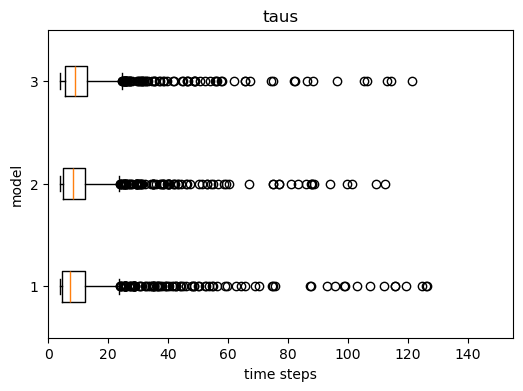

In [12]:
taus_sig = []

for i, model_fname in enumerate(model_names):
    mat_data = scipy.io.loadmat(os.path.join(model_dir, model_fname))
    
    # taus
    taus_gaus = mat_data['taus_gaus'].squeeze()
    taus = mat_data['taus'].squeeze()
    taus_sig.append(1 / (1 + np.exp(-taus_gaus)) * (taus[1] - taus[0]) + taus[0])

taus_sig = np.array(taus_sig)
print(taus_sig.shape)

plt.figure(figsize=(6,4))
plt.boxplot(taus_sig.T, vert=False)
plt.title('taus')
plt.xlim(0, 155)
plt.xlabel('time steps')
plt.ylabel('model')
plt.show()

### performance filter

as a filter, start generating some data for a longer delay (200) and see which models we want to generate more data for

In [7]:
def generate_input_stim_sternberg_stims(settings, stim_ids, max_load=3):
    # use stims to specify which channels to activate for the memory set, 
    # instead of randomly choosing them
    # use inf to indicate non-activated channels for lower loads

    T = int(settings['T'])
    stim_on = int(settings['stim_on'])
    stim_dur = int(settings['stim_dur'])
    delay = int(settings['delay'])
    load = (~np.isinf(stim_ids)).sum() - 1 # count number of non-inf values in stim_ids to determine load
    # load = settings['load'] # int for number of items to remember
    
    n_channels = 4

    # Initialize u
    u = np.zeros((n_channels, T))
    
    # Sternberg task
    for i, i_chan in enumerate(stim_ids[:load]):
        i_chan = int(i_chan) # convert from float to int
        if i == 0:
            u[i_chan, stim_on:stim_on+stim_dur] = 1
            ending_idx = stim_on+stim_dur
        else: # 0 bc no separation btwn stimuli
            u[i_chan, ending_idx+0:ending_idx+stim_dur+0] = 1
            ending_idx = ending_idx+stim_dur+0
    
    probe = int(stim_ids[max_load])
    u[probe, ending_idx+delay:ending_idx+delay+stim_dur] = 1
    label = 1 if stim_ids[max_load] in stim_ids[:load] else -1

    return u, label, stim_ids

In [8]:
from itertools import permutations, product

def get_all_stim_combos():
    values = [0, 1, 2, 3]
    inf = np.inf

    load3 = np.array(
        [
            [a, b, c, probe]
            for a, b, c in permutations(values, 3)
            for probe in values
        ],
        dtype=float
    )

    load2 = np.array(
        [
            [a, b, inf, probe]
            for a, b in permutations(values, 2)
            for probe in values
        ],
        dtype=float
    )

    load1 = np.array(
        [
            [a, inf, inf, probe]
            for a, probe in product(values, repeat=2)
        ],
        dtype=float
    )

    # Combine all loads
    return np.vstack([load3, load2, load1])

stim_combos = get_all_stim_combos()
print(stim_combos.shape)
stim_combos

(160, 4)


array([[ 0.,  1.,  2.,  0.],
       [ 0.,  1.,  2.,  1.],
       [ 0.,  1.,  2.,  2.],
       [ 0.,  1.,  2.,  3.],
       [ 0.,  1.,  3.,  0.],
       [ 0.,  1.,  3.,  1.],
       [ 0.,  1.,  3.,  2.],
       [ 0.,  1.,  3.,  3.],
       [ 0.,  2.,  1.,  0.],
       [ 0.,  2.,  1.,  1.],
       [ 0.,  2.,  1.,  2.],
       [ 0.,  2.,  1.,  3.],
       [ 0.,  2.,  3.,  0.],
       [ 0.,  2.,  3.,  1.],
       [ 0.,  2.,  3.,  2.],
       [ 0.,  2.,  3.,  3.],
       [ 0.,  3.,  1.,  0.],
       [ 0.,  3.,  1.,  1.],
       [ 0.,  3.,  1.,  2.],
       [ 0.,  3.,  1.,  3.],
       [ 0.,  3.,  2.,  0.],
       [ 0.,  3.,  2.,  1.],
       [ 0.,  3.,  2.,  2.],
       [ 0.,  3.,  2.,  3.],
       [ 1.,  0.,  2.,  0.],
       [ 1.,  0.,  2.,  1.],
       [ 1.,  0.,  2.,  2.],
       [ 1.,  0.,  2.,  3.],
       [ 1.,  0.,  3.,  0.],
       [ 1.,  0.,  3.,  1.],
       [ 1.,  0.,  3.,  2.],
       [ 1.,  0.,  3.,  3.],
       [ 1.,  2.,  0.,  0.],
       [ 1.,  2.,  0.,  1.],
       [ 1.,  

In [ ]:
# NOT PARALLELIZED VERSION
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/rate')
import model

import tqdm

n_trials = 50
eval_amp_threshold = 0.7
matches = [0, 1] # 0 for mismatch, 1 for match
loads = [1, 3] # number of items to remember
model_list = model_names

trial_stims = get_all_stim_combos()
trial_stims_test_idxs = []
# pick subset of stim combos to run through for testing

# take all load 1
load1 = np.where(trial_stims[:,1] == np.inf)[0]
trial_stims_test_idxs.extend(load1)

# take some load 3
load3 = np.where(trial_stims[:,1] != np.inf)[0]
match_idxs = [i for i in range(len(load3)) if trial_stims[load3[i], -1] in trial_stims[load3[i], :3]]
load3_match = load3[match_idxs]
mismatch_idxs = [i for i in range(len(load3)) if trial_stims[load3[i], -1] not in trial_stims[load3[i], :3]]
load3_mismatch = load3[mismatch_idxs]
trial_stims_test_idxs.extend(np.random.choice(load3_match, size=16, replace=False))
trial_stims_test_idxs.extend(np.random.choice(load3_mismatch, size=16, replace=False))

print(f'Total stim combos to test: {len(trial_stims_test_idxs)}')

trial_stims_test = trial_stims[trial_stims_test_idxs]

max_load = trial_stims.shape[1] - 1

# delay200
settings = {
        'T': 450, # trial duration (in steps)
        'stim_on': 50, # input stim onset (in steps)
        'stim_dur': 25, # input stim duration (in steps)
        'delay': 200, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'fs': 200,
        'task': 'sternberg', # task name
        'load': 1,
        }

for n_model, model_path in enumerate(model_list):
    model_name = os.path.basename(model_path)
    print(model_name)
    output_dir = model_dir + '/' + model_name[:-4] + '/'
    # os.makedirs(output_dir, exist_ok=True)
    
    # check if saved neural_dict and bhv_dict already
    if os.path.exists(os.path.join(output_dir, f'neural_dict_delay{settings["delay"]}.pkl')) and os.path.exists(os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}.pkl')):
        print(f'skipping {model_name}, already saved')
        continue
    
    loads = []
    perfs = []
    
    # time this loop to see how long it takes to run through all stim combos for one model
    pbar = tqdm.tqdm(trial_stims_test)
    for stim_ids in pbar:
        # print(stim_ids)

        # compute load from inf mask (same logic as before)
        load = (~np.isinf(stim_ids)).sum() - 1

        local_settings = settings.copy()
        local_settings['load'] = int(load)

        resp_onset = (
            local_settings['stim_on']
            + load * local_settings['stim_dur']
            + local_settings['delay']
            + 10
        )

        u, label, stim_ids_used = generate_input_stim_sternberg_stims(
                local_settings,
                stim_ids,
                max_load=max_load
            )
        
        _, r, o, epsp = model.eval_tf(
                model_dir=f'{model_dir}/{model_name}',
                settings=local_settings,
                u=u,
                calc_epsp=True
            )

        # Behavioral performance
        if label == 1:
            perf = int(np.max(o[resp_onset:]) > eval_amp_threshold)
        else:
            perf = int(np.min(o[resp_onset:]) < -eval_amp_threshold)
        perfs.append(perf)
        loads.append(load)
    
    print(f'Model: {model_name}, Average performance across all stim combos: {np.mean(perfs)}')
    
    if np.mean(perfs) < 0.5:
        print(f'Model {model_name} has poor performance. Moving to low perf folder.')
        lowperf_path = os.path.join(model_dir, 'low_perf', model_name)
        os.rename(model_path, lowperf_path)

Total stim combos to test: 48
Task_sternberg_N_1000_Jitter_5_3_2026_04_17_163426.mat


100%|██████████| 48/48 [04:14<00:00,  5.31s/it]


Model: Task_sternberg_N_1000_Jitter_5_3_2026_04_17_163426.mat, Average performance across all stim combos: 0.4375
Model Task_sternberg_N_1000_Jitter_5_3_2026_04_17_163426.mat has poor performance. Moving to low perf folder.
Task_sternberg_N_1000_Jitter_5_3_2026_04_17_142450.mat


  8%|▊         | 4/48 [00:24<04:24,  6.02s/it]


KeyboardInterrupt: 

In [9]:
import os
import sys
import numpy as np
from joblib import Parallel, delayed
import tqdm

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/rate')
import model

eval_amp_threshold = 0.7

rng = np.random.default_rng(0)  # reproducible

# Build this once in the parent process
trial_stims = get_all_stim_combos()
trial_stims_test_idxs = []

# take all load 1
load1 = np.where(trial_stims[:, 1] == np.inf)[0]
trial_stims_test_idxs.extend(load1)

# take some load 2
load2 = np.where((trial_stims[:, 1] != np.inf) & (trial_stims[:, 2] == np.inf))[0]
load2_match_idxs = [i for i in range(len(load2)) if trial_stims[load2[i], -1] in trial_stims[load2[i], :3]]
load2_mismatch_idxs = [i for i in range(len(load2)) if trial_stims[load2[i], -1] not in trial_stims[load2[i], :3]]
load2_match = load2[load2_match_idxs]
load2_mismatch = load2[load2_mismatch_idxs]
trial_stims_test_idxs.extend(rng.choice(load2_match, size=16, replace=False))
trial_stims_test_idxs.extend(rng.choice(load2_mismatch, size=16, replace=False))

# take some load 3
load3 = np.where(trial_stims[:, 2] != np.inf)[0]
match_idxs = [i for i in range(len(load3)) if trial_stims[load3[i], -1] in trial_stims[load3[i], :3]]
mismatch_idxs = [i for i in range(len(load3)) if trial_stims[load3[i], -1] not in trial_stims[load3[i], :3]]
load3_match = load3[match_idxs]
load3_mismatch = load3[mismatch_idxs]
trial_stims_test_idxs.extend(rng.choice(load3_match, size=16, replace=False))
trial_stims_test_idxs.extend(rng.choice(load3_mismatch, size=16, replace=False))

trial_stims_test = trial_stims[trial_stims_test_idxs]
max_load = trial_stims.shape[1] - 1

settings = {
    'T': 450,
    'stim_on': 50,
    'stim_dur': 25,
    'delay': 200,
    'DeltaT': 1,
    'taus': 20,
    'fs': 200,
    'task': 'sternberg',
    'load': 1,
}


def evaluate_one_model(model_path, model_dir, trial_stims_test, max_load, settings, eval_amp_threshold):
    model_name = os.path.basename(model_path)
    output_dir = os.path.join(model_dir, model_name[:-4])

    neural_path = os.path.join(output_dir, f'neural_dict_delay{settings["delay"]}.pkl')
    bhv_path = os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}.pkl')

    if os.path.exists(neural_path) and os.path.exists(bhv_path):
        return {
            "model_name": model_name,
            "status": "skipped",
            "mean_perf": None,
        }

    loads = []
    perfs = []

    for stim_ids in trial_stims_test:
        load = (~np.isinf(stim_ids)).sum() - 1

        local_settings = settings.copy()
        local_settings['load'] = int(load)

        resp_onset = (
            local_settings['stim_on']
            + load * local_settings['stim_dur']
            + local_settings['delay']
            + 10
        )

        u, label, stim_ids_used = generate_input_stim_sternberg_stims(
            local_settings,
            stim_ids,
            max_load=max_load
        )

        _, r, o, epsp = model.eval_tf(
            model_dir=os.path.join(model_dir, model_name),
            settings=local_settings,
            u=u,
            calc_epsp=True
        )

        if label == 1:
            perf = int(np.max(o[resp_onset:]) > eval_amp_threshold)
        else:
            perf = int(np.min(o[resp_onset:]) < -eval_amp_threshold)

        perfs.append(perf)
        loads.append(load)

    mean_perf = float(np.mean(perfs))

    if mean_perf < 0.5:
        lowperf_dir = os.path.join(model_dir, 'low_perf')
        os.makedirs(lowperf_dir, exist_ok=True)
        lowperf_path = os.path.join(lowperf_dir, model_name)

        if os.path.exists(model_path) and not os.path.exists(lowperf_path):
            os.rename(model_path, lowperf_path)

        status = "moved_low_perf"
    else:
        status = "done"

    return {
        "model_name": model_name,
        "status": status,
        "mean_perf": mean_perf,
    }


results = Parallel(n_jobs=4, backend="loky", verbose=10)(
    delayed(evaluate_one_model)(
        model_path,
        model_dir,
        trial_stims_test,
        max_load,
        settings,
        eval_amp_threshold
    )
    for model_path in model_names
)

for res in results:
    print(res)

Instructions for updating:
non-resource variables are not supported in the long term


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
2026-06-03 14:12:45.343989: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-03 14:12:45.344125: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-03 14:12:45.352797: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-03 14:12:45.353025: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: At

{'model_name': 'Task_sternberg_N_1000_Jitter_5_3_2026_06_03_000020.mat', 'status': 'done', 'mean_perf': 0.55}
{'model_name': 'Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901.mat', 'status': 'done', 'mean_perf': 0.6875}
{'model_name': 'Task_sternberg_N_1000_Jitter_5_3_2026_06_03_034721.mat', 'status': 'done', 'mean_perf': 0.675}


[Parallel(n_jobs=4)]: Done   3 out of   3 | elapsed:  8.3min finished


In [10]:
results

[{'model_name': 'Task_sternberg_N_1000_Jitter_5_3_2026_06_03_000020.mat',
  'status': 'done',
  'mean_perf': 0.55},
 {'model_name': 'Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901.mat',
  'status': 'done',
  'mean_perf': 0.6875},
 {'model_name': 'Task_sternberg_N_1000_Jitter_5_3_2026_06_03_034721.mat',
  'status': 'done',
  'mean_perf': 0.675}]

In [33]:
model_dir = '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5'

model_names = find_files(model_dir, '*N_1000*.mat')
print(len(model_names))
print(model_names)

23
['/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_17_142450.mat', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_14_044205.mat', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_14_013441.mat', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_17_174533.mat', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_17_174229.mat', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_17_143257.mat', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_17_172549.mat', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_17_155940.mat', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/